In [19]:
import anndata as ad
from collections import Counter
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scanpy as sc
from scipy.stats import kruskal, mannwhitneyu, false_discovery_control
from skbio.stats.composition import clr, multiplicative_replacement
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

main_path = os.getcwd()

import sys
sys.path.append(main_path)

from analysis.libraries.clinical import load_clinical
from analysis.libraries.data_processing import match_core_to_ACA

In [2]:
import matplotlib as mpl

mpl.rcParams["pdf.use14corefonts"] = True
mpl.rcParams['pdf.fonttype'] = 42

In [3]:
adata = ad.read_h5ad(os.path.join(main_path, 'data/LATTICeA_io_adata_ssl_leiden_224px_fold0.h5ad'))
adata.obs

/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,CellX,CellY,Core,TMA,Core_ID,Region,AreaCell,t_CellX,t_CellY,kmeans_5,kmeans_10,cell_lineage,y_start,y_stop,x_start,x_stop,leiden
0,8526.375294,-47209.294961,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,92.647581,223.004094,-134.923761,0,0,CKPAN,111.3728,222.7456,222.7456,334.1184,2
1,8502.780534,-47222.466136,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,106.730014,199.409334,-148.094936,0,0,CKPAN,111.3728,222.7456,111.3728,222.7456,NaN
2,8510.929662,-47224.074935,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,42.000237,207.558462,-149.703735,0,9,CKPAN,111.3728,222.7456,111.3728,222.7456,NaN
3,8517.623256,-47224.496313,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,72.882764,214.252056,-150.125113,0,0,CKPAN,111.3728,222.7456,111.3728,222.7456,NaN
4,8522.685445,-47229.076912,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Stroma,35.082551,219.314245,-154.705712,1,8,CD68,111.3728,222.7456,111.3728,222.7456,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16815638,8311.875731,-53930.612326,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,92.153461,717.504531,-1115.241126,2,4,CD4,1113.7280,1225.1008,668.2368,779.6096,NaN
16815639,8433.799791,-53929.827897,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,58.059151,839.428591,-1114.456697,1,8,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN
16815640,8299.651795,-53932.267364,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,98.577027,705.280595,-1116.896164,1,8,CD68,1113.7280,1225.1008,668.2368,779.6096,NaN
16815641,8411.888971,-53932.588400,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Tumour,104.259412,817.517771,-1117.217200,1,2,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN


In [4]:
cores_df = pd.read_csv(os.path.join(main_path, 'data/metadata/tma-core-metadata.csv'))


bioclavis_cores = adata.obs['Core_ID'].unique()
bioclavis_core_dict = dict()

for core in bioclavis_cores:
    bioclavis_core_dict[core] = match_core_to_ACA(core, cores_df)

# adata = adata[~adata.obs['leiden'].isna()]
adata.obs

,CellX,CellY,Core,TMA,Core_ID,Region,AreaCell,t_CellX,t_CellY,kmeans_5,kmeans_10,cell_lineage,y_start,y_stop,x_start,x_stop,leiden
0,8526.375294,-47209.294961,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,92.647581,223.004094,-134.923761,0,0,CKPAN,111.3728,222.7456,222.7456,334.1184,2
1,8502.780534,-47222.466136,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,106.730014,199.409334,-148.094936,0,0,CKPAN,111.3728,222.7456,111.3728,222.7456,NaN
2,8510.929662,-47224.074935,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,42.000237,207.558462,-149.703735,0,9,CKPAN,111.3728,222.7456,111.3728,222.7456,NaN
3,8517.623256,-47224.496313,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,72.882764,214.252056,-150.125113,0,0,CKPAN,111.3728,222.7456,111.3728,222.7456,NaN
4,8522.685445,-47229.076912,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Stroma,35.082551,219.314245,-154.705712,1,8,CD68,111.3728,222.7456,111.3728,222.7456,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16815638,8311.875731,-53930.612326,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,92.153461,717.504531,-1115.241126,2,4,CD4,1113.7280,1225.1008,668.2368,779.6096,NaN
16815639,8433.799791,-53929.827897,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,58.059151,839.428591,-1114.456697,1,8,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN
16815640,8299.651795,-53932.267364,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,98.577027,705.280595,-1116.896164,1,8,CD68,1113.7280,1225.1008,668.2368,779.6096,NaN
16815641,8411.888971,-53932.588400,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Tumour,104.259412,817.517771,-1117.217200,1,2,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN


In [5]:
adata.obs = adata.obs.replace({'CKPAN':'panCK'})

In [6]:
# Bioclavis SSL data 

panel_name = 'latticea-io'
adata_path = os.path.join(main_path, 'data', 'ssl_adata', panel_name)

ssl_bioclavis_train = ad.read_h5ad(os.path.join(adata_path, 'adata-train.hdf5'))
ssl_bioclavis_valid = ad.read_h5ad(os.path.join(adata_path, 'adata-valid.hdf5'))

ssl_bioclavis_train.obs['samples'] = ssl_bioclavis_train.obs['sample_id'].apply(lambda x: x[:8])
ssl_bioclavis_valid.obs['samples'] = ssl_bioclavis_valid.obs['sample_id'].apply(lambda x: x[:8])

ssl_bioclavis_train.obs.rename(columns={'sample_id':'core'}, inplace=True)
ssl_bioclavis_valid.obs.rename(columns={'sample_id':'core'}, inplace=True)

ssl_bioclavis_train.obs['core'] = ssl_bioclavis_train.obs['core'].apply(lambda x: x.split('_')[-1])
ssl_bioclavis_valid.obs['core'] = ssl_bioclavis_valid.obs['core'].apply(lambda x: x.split('_')[-1])

ssl_bioclavis_train.obs['original_set'] = 'train'
ssl_bioclavis_valid.obs['original_set'] = 'valid'

In [ ]:
train_samples = ssl_bioclavis_train.obs['samples'].unique()
valid_samples = ssl_bioclavis_valid.obs['samples'].unique()

In [ ]:
train_samples.shape, valid_samples.shape

((508,), (494,))

In [9]:
survival, clinpath, patterns = load_clinical(main_path=main_path)

survival['Survival Status'] = survival['Survival Status'].replace({'Dead':1, 'Alive':0})
survival['Time to Survival Status (Days)'] = survival['Time to Survival Status (Days)'] / 365 * 12

survival = survival.rename(columns={'Survival Status':'os_event_ind',
                                    'Time to Survival Status (Days)':'os_event_data'})

survival_no_mucin = survival[~survival['2015 WHO Classification'].isin(['Invasive mucinous adenocarcinoma (IMA)', 'Not given'])]

/mnt/cephfs/sharedscratch/users/krakovic/MultiplexSSL/analysis/libraries/clinical.py:8: DtypeWarning: Columns (2,10,30,37,38,52,67,84,85,110,118,134,135,136,137,138,148,149,150,217,219,221,223,224,225,226,236,242,243,244,245,248,249,250,251,252,253,254,255,256,257,261,262,263,264,265,266,267,268,269,270,271,280,282,283,285,288,289,294,295,298,299,310,311,312,313,314,315,316,317,340,374,440,441,442,443,446,447,448,449,450,451,452,453,454,455,459,460,461,462,463,464,465,466,467,468,469,481,487,508,509,510,511,512,513,514,515,538,572,638,639,640,641,644,645,646,647,648,649,650,651,652,653,657,658,659,660,661,662,663,664,665,666,667,679,685,706,707,708,709,710,711,712,713,736,770,834,835,836,839,863,887) have mixed types. Specify dtype option on import or set low_memory=False.
  clinpath = pd.read_csv(os.path.join(main_path, 'data/metadata/latticea_master_clinicopathological.csv'))


## Cell density

In [10]:
core_areas = pd.read_csv(os.path.join(main_path, 'data/metadata/processed_core_areas.csv'), index_col=0).sort_values(by='core')

In [11]:
core_densities = pd.DataFrame()
all_cores = adata.obs['Core_ID'].unique()

for i, core in enumerate(all_cores):
    phenotypes, counts = np.unique(adata.obs[adata.obs['Core_ID'] == core]['cell_lineage'].values, return_counts=True)
    core_densities.loc[i, 'core'] = core
    for j, _ in enumerate(phenotypes):
        core_densities.loc[i, phenotypes[j]] = counts[j]

core_densities = core_densities.fillna(0)

core_densities

,core,CD4,CD68,CD8,Negative,SMA,panCK
0,22-05-J,99.0,456.0,85.0,4504.0,90.0,3327.0
1,22-10-B,3397.0,732.0,473.0,2485.0,36.0,2001.0
2,22-04-B,365.0,899.0,410.0,4138.0,705.0,1286.0
3,22-03-B,27.0,237.0,23.0,2853.0,481.0,58.0
4,22-15-H,990.0,993.0,1663.0,4830.0,340.0,38.0
...,...,...,...,...,...,...,...
2656,19-10-C,87.0,321.0,26.0,1851.0,217.0,1563.0
2657,19-03-D,1459.0,1112.0,488.0,2985.0,896.0,2176.0
2658,19-05-J,29.0,108.0,14.0,3658.0,199.0,1079.0
2659,19-06-I,403.0,784.0,154.0,2028.0,983.0,377.0


In [12]:
core_densities['samples'] = core_densities['core'].map(bioclavis_core_dict)
core_densities = core_densities.sort_values(by='core')
core_densities = core_densities.merge(core_areas[['core', 'area_mm2']], on='core')
core_densities

,core,CD4,CD68,CD8,Negative,SMA,panCK,samples,area_mm2
0,01-02-A,378.0,1076.0,154.0,4160.0,407.0,1133.0,ACA_0296,0.907125
1,01-02-B,574.0,464.0,312.0,3634.0,420.0,1340.0,ACA_0090,0.863007
2,01-02-C,332.0,520.0,75.0,2905.0,566.0,720.0,ACA_0040,0.659490
3,01-02-D,103.0,837.0,30.0,2489.0,132.0,535.0,ACA_0008,0.894065
4,01-02-F,655.0,1141.0,83.0,1820.0,902.0,1289.0,ACA_0096,0.852319
...,...,...,...,...,...,...,...,...,...
2655,23-15-F,64.0,117.0,25.0,2380.0,354.0,205.0,ACA_1093,0.610211
2656,23-15-G,342.0,526.0,170.0,3119.0,461.0,340.0,ACA_1099,0.954593
2657,23-15-H,280.0,450.0,292.0,5414.0,468.0,193.0,ACA_1104,0.923159
2658,23-15-I,112.0,345.0,168.0,2070.0,69.0,135.0,ACA_1108,0.548292


In [13]:
for marker in ['panCK', 'CD8', 'CD4', 'CD68', 'SMA', 'Negative']:
    core_densities[f'{marker}_mm2'] = np.log10(core_densities[marker] / core_densities['area_mm2'] + 0.01)

In [14]:
core_densities = core_densities.drop(labels=['area_mm2'], axis=1)

In [15]:
core_densities_mm2 = core_densities[[col for col in core_densities if '_mm2' in col]+['samples']]
core_densities_mm2 = core_densities_mm2.groupby('samples').agg('mean').reset_index()
core_densities_mm2

,samples,panCK_mm2,CD8_mm2,CD4_mm2,CD68_mm2,SMA_mm2,Negative_mm2
0,ACA_0001,2.915643,2.487397,2.538477,3.162085,2.268266,3.469683
1,ACA_0002,2.873368,1.845474,1.820421,2.493054,2.603436,3.495435
2,ACA_0003,2.990312,1.925276,2.778493,3.063051,2.914036,3.489172
3,ACA_0004,2.573558,2.752955,2.995774,3.021526,2.641537,3.591560
4,ACA_0005,3.045670,2.094090,2.661131,2.533587,2.857373,3.319228
...,...,...,...,...,...,...,...
998,ACA_1109,2.601787,2.154314,2.255101,2.720992,2.681372,3.495109
999,ACA_1110,3.372226,2.683523,2.930923,3.026985,2.143782,3.366788
1000,ACA_1112,2.852173,2.434929,2.615891,3.026604,2.143838,3.535637
1001,ACA_1115,3.336825,1.825407,2.328863,2.735606,2.407992,3.567767


In [16]:
train_densities = core_densities_mm2[core_densities_mm2['samples'].isin(train_samples)]
valid_densities = core_densities_mm2[core_densities_mm2['samples'].isin(valid_samples)]

In [17]:
train_densities_survival = train_densities.merge(survival_no_mucin[['samples', 'os_event_ind', 'os_event_data']], on='samples').dropna()
valid_densities_survival = valid_densities.merge(survival_no_mucin[['samples', 'os_event_ind', 'os_event_data']], on='samples').dropna()

In [20]:
cph = CoxPHFitter()

cph.fit(train_densities_survival.drop(labels=['samples', 'Negative_mm2'], axis=1), duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 470 total observations, 135 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
      baseline estimation = breslow
   number of observations = 470
number of events observed = 335
   partial log-likelihood = -1797.98
         time fit was run = 2025-10-13 16:06:29 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
panCK_mm2  -0.00       1.00       0.11            -0.22             0.21                 0.80                 1.23
CD8_mm2    -0.33       0.72       0.16            -0.64            -0.01                 0.52                 0.99
CD4_mm2    -0.06       0.94       0.16            -0.37             0.25                 0.69                 1.28
CD68_mm2    0.04       1.04       0.29            -0.53             0.61                 0.59                 1.85
SMA_mm2    -0.24       0.79       0.17            -0.57             0.08                 0.57                 1.09

            cmp to     z    p   -log2(p)
covariate                               
panCK_mm2     0.00 -0.04 0.96       0.05
CD8_mm2       0.00 -2.01 0.04       4.50
CD4_mm2       0.00 -0.39 0.70       0.52
CD68_mm2      0.00  0.14 0.89       0.17
SMA_mm2       0.00 -1.46 0.15       2.78
---
Concordance = 0.55
Partial AIC = 3605.96
log-likelihood ratio test = 11.75 on 5 df
-log2(p) of ll-ratio test = 4.70

[Text(0, 0, 'CD8+ T-cells'),
 Text(0, 1, 'SMA+ cells'),
 Text(0, 2, 'CD4+ T-cells'),
 Text(0, 3, 'panCK'),
 Text(0, 4, 'CD68+ Macrophages')]

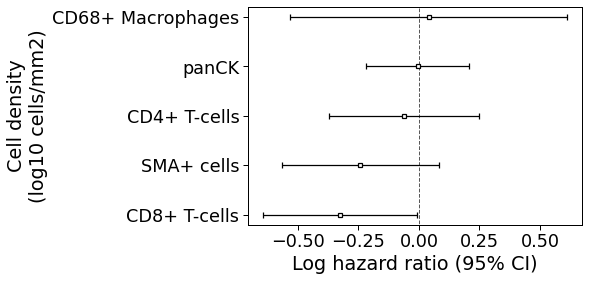

In [21]:
sns.set_context("paper", font_scale=2.0)

fig, ax = plt.subplots(figsize=(6,4))

cph.plot(ax=ax)
ax.set_xlabel('Log hazard ratio (95% CI)')
ax.set_ylabel('Cell density\n(log10 cells/mm2)')
ax.set_yticklabels(['CD68+ Macrophages', 'panCK', 'CD4+ T-cells', 'SMA+ cells', 'CD8+ T-cells'][::-1])
# ax.set_title('Cell density')

In [22]:
cph.concordance_index_

0.5512805031998859

In [23]:
valid_ci = concordance_index(valid_densities_survival['os_event_data'], -cph.predict_partial_hazard(valid_densities_survival[[col for col in valid_densities_survival if '_mm2' in col]]), valid_densities_survival['os_event_ind'])
valid_ci

0.5383565349992622

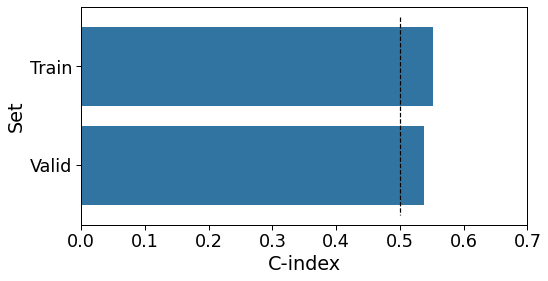

In [24]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=[cph.concordance_index_, valid_ci], y=['Train', 'Valid'], orient='h', ax=ax)
ax.set_xlabel('C-index')
ax.set_ylabel('Set')
ax.set_xlim([0,0.7])
ax.vlines(x=0.5, ymin=-0.5, ymax=1.5, color='black', linestyle='--')

### Split by CD8

In [25]:
median_cd8 = train_densities_survival['CD8_mm2'].median()

In [26]:
train_densities_survival['cd8_high'] = train_densities_survival['CD8_mm2'].apply(lambda x: 1 if x > median_cd8 else 0)
valid_densities_survival['cd8_high'] = valid_densities_survival['CD8_mm2'].apply(lambda x: 1 if x > median_cd8 else 0)

In [27]:
train_densities_survival.shape[0], valid_densities_survival.shape[0]

(470, 452)

In [28]:
all_densities_survival = pd.concat([train_densities_survival, valid_densities_survival])
all_median_cd8 = all_densities_survival['CD8_mm2'].median()

all_densities_survival['cd8_high'] = all_densities_survival['CD8_mm2'].apply(lambda x: 1 if x > all_median_cd8 else 0)

In [29]:
all_densities_survival['cd8_high'].value_counts()

0    461
1    461
Name: cd8_high, dtype: int64

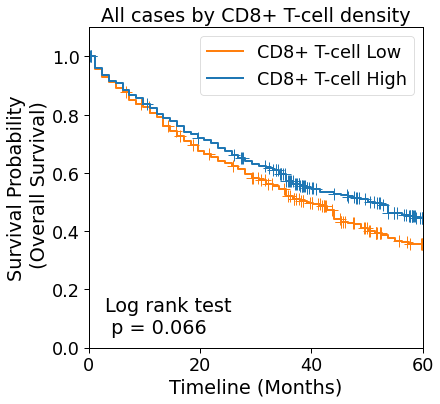

In [31]:
from analysis.libraries.survival import plot_km_two_groups

sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(6.5,6))

plot_km_two_groups(df=all_densities_survival.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='cd8_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='All cases by CD8+ T-cell density', 
                   ci_show=False, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'CD8+ T-cell Low', f'CD8+ T-cell High'])  